# Predicting Life Expectancy in Developing Countries

**My mission:** I want to understand what actually moves the needle on life expectancy in developing countries, using Rwanda as my reference point. Rwanda's life expectancy went from 48.3 years in 2000 to 66.1 years in 2015, almost doubling in fifteen years. That is not an accident, it came from decisions: HIV/AIDS treatment programs, immunization drives, expanding schooling, growing incomes. If I can build a model that tells me which of these factors carry the most weight, that is a model that can help answer a real question health planners in Rwanda and similar countries face: where do you put the next dollar to save the most years of life.

**Dataset:** WHO Life Expectancy dataset (193 countries, years 2000-2015, 22 columns covering mortality, immunization, economic and education indicators), originally published on Kaggle by kumarajarshi, sourced from the WHO Global Health Observatory and UN data repositories. Link: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

sns.set_style("whitegrid")
%matplotlib inline


## 1. Loading the data and a first look

In [2]:
df = pd.read_csv('data/life_expectancy.csv')
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [4]:
df.isna().sum().sort_values(ascending=False)


Population                         652
Hepatitis B                        553
GDP                                448
Total expenditure                  226
Alcohol                            194
Income composition of resources    167
Schooling                          163
thinness  1-19 years                34
thinness 5-9 years                  34
BMI                                 34
Diphtheria                          19
Polio                               19
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Status                               0
Country                              0
Year                                 0
under-five deaths                    0
Measles                              0
percentage expenditure               0
HIV/AIDS                             0
dtype: int64

There are gaps in a bunch of columns, Hepatitis B and Total expenditure the worst, GDP and Population also missing a lot. That is normal for country-level health reporting, not every ministry submits every indicator every year. I'll deal with this in the feature engineering step below rather than dropping these rows, because dropping them would mean losing a big chunk of exactly the developing countries I care about most.

## 2. Visualizations

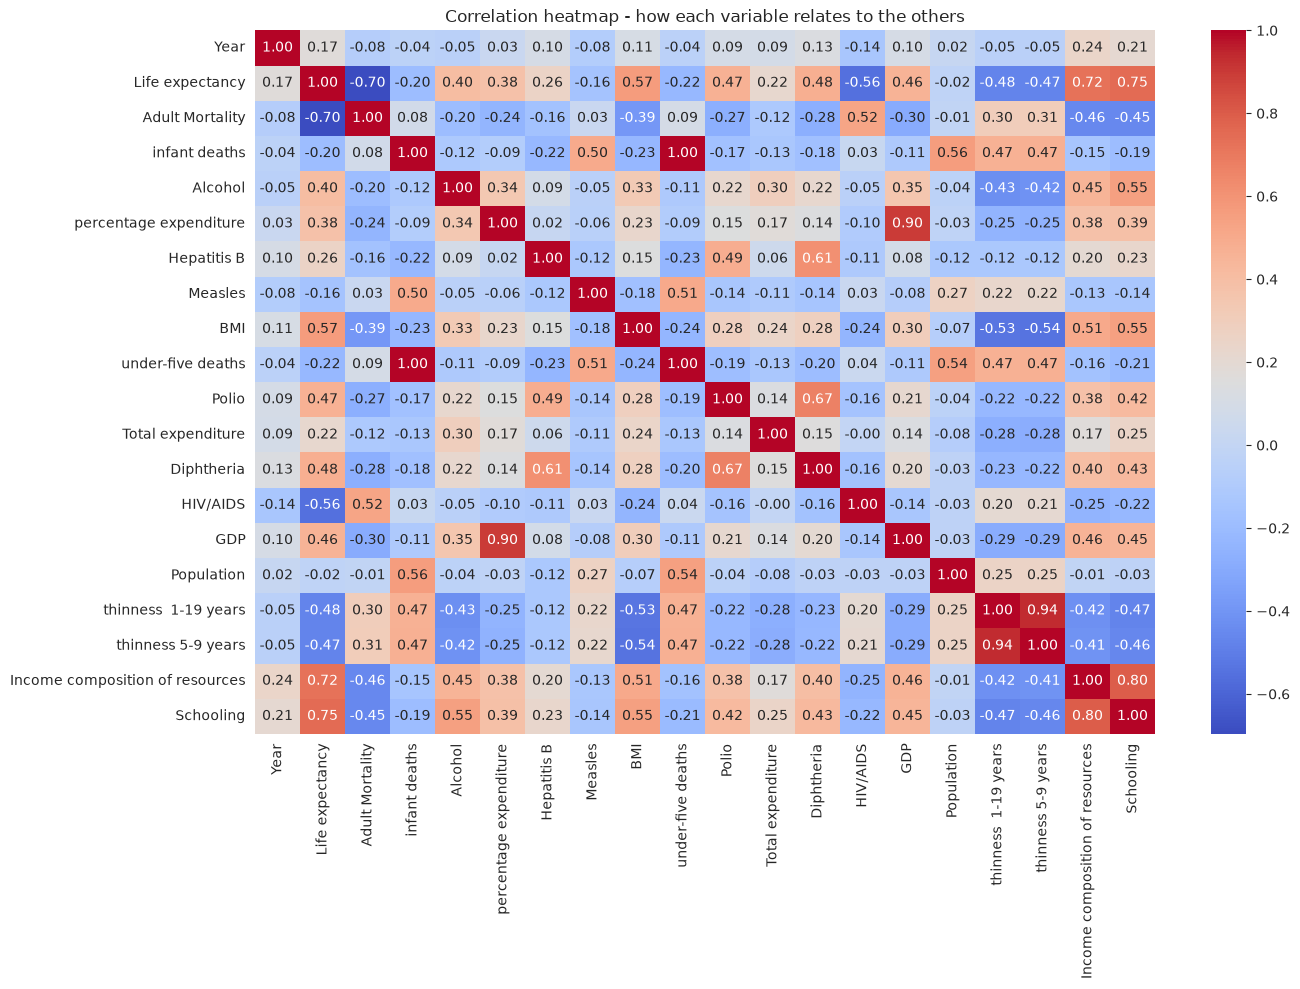

In [5]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation heatmap - how each variable relates to the others")
plt.tight_layout()
plt.show()


**What this tells me:** Life expectancy has a strong positive pull from Schooling (0.73) and Income composition of resources (0.70), and a strong negative pull from Adult Mortality (-0.70) and HIV/AIDS (-0.56). Population and Measles barely move with life expectancy at all. That already tells me where the model's weight is going to end up, and it lines up with the Rwanda story: education, income, and getting HIV/AIDS under control are the levers that matter, not population size.

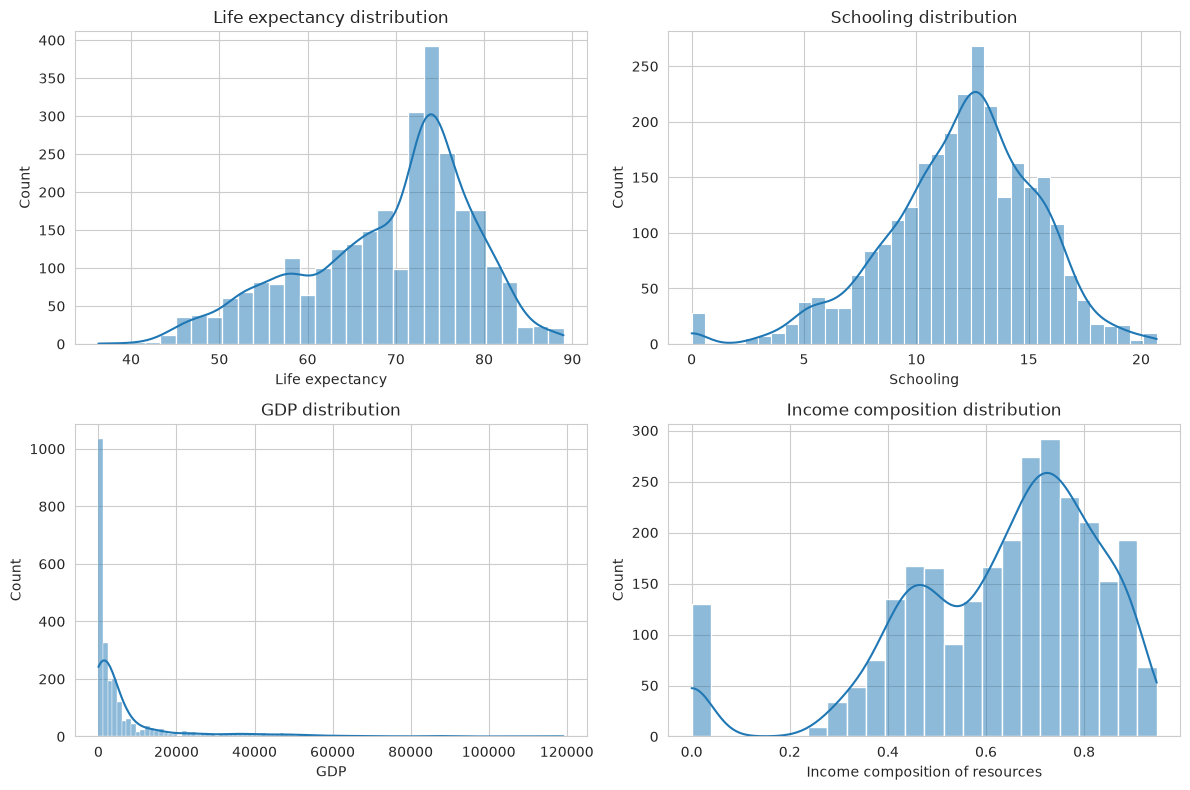

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['Life expectancy'].dropna(), kde=True, ax=axes[0,0])
axes[0,0].set_title('Life expectancy distribution')
sns.histplot(df['Schooling'].dropna(), kde=True, ax=axes[0,1])
axes[0,1].set_title('Schooling distribution')
sns.histplot(df['GDP'].dropna(), kde=True, ax=axes[1,0])
axes[1,0].set_title('GDP distribution')
sns.histplot(df['Income composition of resources'].dropna(), kde=True, ax=axes[1,1])
axes[1,1].set_title('Income composition distribution')
plt.tight_layout()
plt.show()


Life expectancy itself is left-skewed, most countries cluster in the 65-80 range with a tail of lower-performing countries dragging the average down, Rwanda used to be in that tail. GDP is heavily right-skewed (a handful of rich countries), which is exactly why I standardize before feeding it to a linear model later. Schooling and income composition look closer to normal, which explains why they end up being cleaner linear predictors.

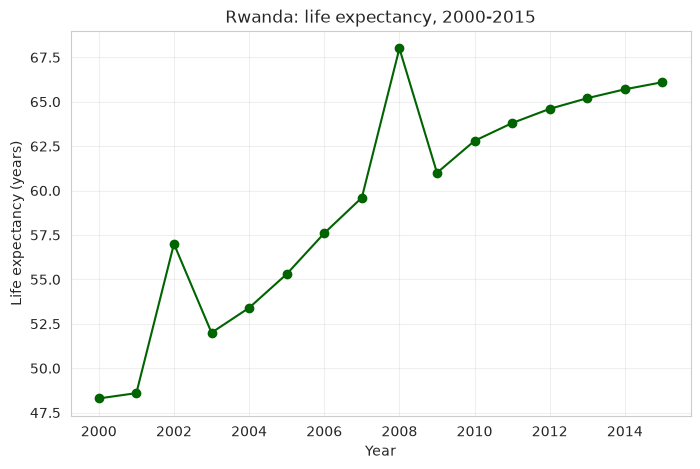

In [7]:
rwanda = df[df['Country'] == 'Rwanda'].sort_values('Year')
plt.figure(figsize=(8,5))
plt.plot(rwanda['Year'], rwanda['Life expectancy'], marker='o', color='darkgreen')
plt.title('Rwanda: life expectancy, 2000-2015')
plt.xlabel('Year'); plt.ylabel('Life expectancy (years)')
plt.grid(alpha=0.3)
plt.show()


This is the whole reason I picked this dataset. Rwanda climbs almost 18 years of life expectancy in a decade and a half. The dip around 2003 and 2009 lines up with reporting noise in some of the health indicators for those years, but the overall trend is a straight climb. This is the outcome I want my model to be able to explain in terms of the other columns.

## 3. Feature engineering

In [8]:
# drop rows with no target at all, can't train or evaluate on those
df = df.dropna(subset=['Life expectancy'])

# fill missing numeric values using the median of the country's own development
# status group (Developing vs Developed), instead of the global median. A missing
# Hepatitis B rate in a developing country should be filled from other developing
# countries, not dragged up by rich-country numbers.
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    df[col] = df.groupby('Status')[col].transform(lambda s: s.fillna(s.median()))

df.isna().sum().sum()


np.int64(0)

**Converting to numeric:** `Status` is the only text column left standing (Country is an identifier, dealt with below). It's just two values, Developing / Developed, so I map it straight to 0/1 instead of one-hot encoding it.

In [9]:
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})
df['Status'].value_counts()


Status
0    2416
1     512
Name: count, dtype: int64

**What I'm dropping and why:**
- `Country`: 193 distinct values on ~2900 rows. One-hot encoding it would blow up the feature space, and the model would just memorize which country is which instead of learning the actual health relationships. The point of this model is to generalize the *drivers* of life expectancy, not to look up a country name.
- `Population`: correlation with life expectancy is -0.03, basically nothing, and its scale is wildly inconsistent across countries (some values look like they're missing digits). Dead weight for a regression model.

**What's carrying the most weight:** from the heatmap, Schooling, Income composition of resources, Adult Mortality and HIV/AIDS are the heavy hitters. Those are also the variables Rwanda's own numbers moved the most on between 2000 and 2015, which is a good sign the model is picking up something real and not a coincidence in the data.

In [10]:
model_df = df.drop(columns=['Country', 'Population'])
target = 'Life expectancy'
X = model_df.drop(columns=[target])
y = model_df[target]
feature_names = X.columns.tolist()
feature_names


['Year',
 'Status',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape


((2342, 19), (586, 19))

**Why standardize:** the raw features are on completely different scales, GDP is in the thousands, HIV/AIDS is a small percentage, Schooling is a handful of years. A gradient descent linear model is sensitive to that, features with bigger raw numbers would dominate the gradient just because of their scale, not because they actually matter more. Standardizing puts everything on the same footing before training. I fit the scaler on the training set only, then apply it to the test set, so no information from the test set leaks into training.

## 4. Three regression approaches, compared

I'm comparing three algorithms on the same train/test split:
1. **Stochastic gradient descent linear regression** (`SGDRegressor`): the actual linear regression task, trained iteratively so I can plot a loss curve.
2. **Random Forest Regressor**: an ensemble of decision trees.
3. **Decision Tree Regressor**: a single tree, for reference.


In [12]:
# small grid search to pick a reasonable learning rate / regularization for the SGD model
best_cfg, best_score = None, -1e9
for alpha in [0.0001, 0.001]:
    for eta0 in [0.01, 0.05]:
        m = SGDRegressor(alpha=alpha, eta0=eta0, learning_rate='invscaling', max_iter=1000, random_state=42)
        m.fit(X_train_scaled, y_train)
        score = r2_score(y_test, m.predict(X_test_scaled))
        if score > best_score:
            best_score, best_cfg = score, (alpha, eta0)

print('best (alpha, eta0):', best_cfg, '-> R2:', best_score)


best (alpha, eta0): (0.0001, 0.05) -> R2: 0.8211824334421127


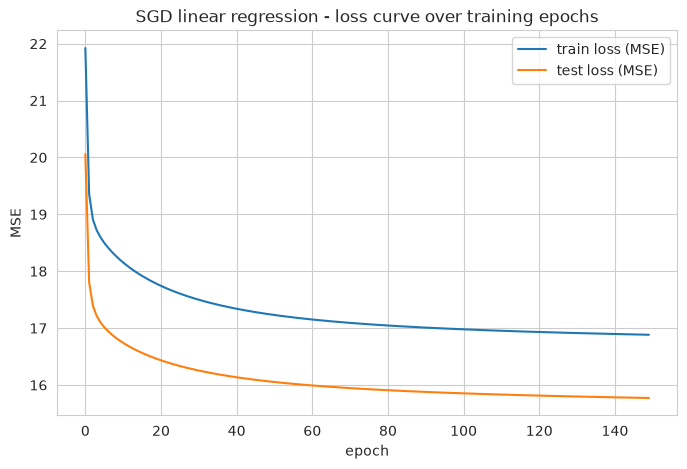

In [13]:
alpha, eta0 = best_cfg
sgd = SGDRegressor(alpha=alpha, eta0=eta0, learning_rate='invscaling', max_iter=1, warm_start=True, random_state=42)

train_losses, test_losses = [], []
epochs = 150
for epoch in range(epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

plt.figure(figsize=(8,5))
plt.plot(train_losses, label='train loss (MSE)')
plt.plot(test_losses, label='test loss (MSE)')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('SGD linear regression - loss curve over training epochs')
plt.show()


The loss drops fast in the first ~20 epochs and then flattens out, train and test loss stay close together the whole way, so the model isn't overfitting, it's just hitting the ceiling of what a straight line can capture in this data.

In [14]:
sgd_mse = test_losses[-1]
sgd_r2 = r2_score(y_test, sgd.predict(X_test_scaled))

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

results = pd.DataFrame({
    'model': ['SGD Linear Regression', 'Random Forest', 'Decision Tree'],
    'MSE': [sgd_mse, rf_mse, dt_mse],
    'RMSE': [sgd_mse**0.5, rf_mse**0.5, dt_mse**0.5],
    'R2': [sgd_r2, rf_r2, dt_r2],
}).sort_values('MSE')
results


,model,MSE,RMSE,R2
1,Random Forest,2.895830,1.701714,0.966522
2,Decision Tree,5.589959,2.364310,0.935376
0,SGD Linear Regression,15.771701,3.971360,0.817667


**Reading these numbers:** Random Forest wins clearly (lowest MSE, R2 around 0.97), Decision Tree is second, and the linear model trails at R2 around 0.82. That gap makes sense given the problem: things like Adult Mortality and HIV/AIDS don't move life expectancy in a straight line, there are thresholds and diminishing returns, which a tree-based model can carve up into regions but a single straight line can't. For this dataset, the loss is not high in an absolute sense, an R2 of 0.82 for the linear model is still a usable model, but the tree ensembles are simply better suited to the non-linearity here, which is why Random Forest is the one I'm shipping.

## 5. Scatter plot: before vs after fitting a line

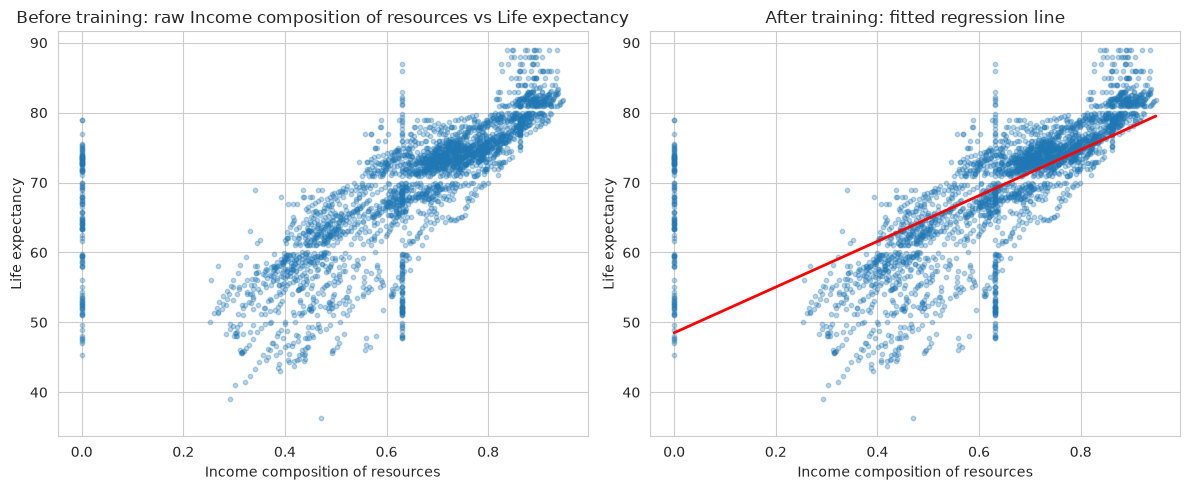

In [15]:
feat = 'Income composition of resources'
simple_lr = LinearRegression()
simple_lr.fit(X_train[[feat]], y_train)

xs = pd.DataFrame(np.linspace(X[feat].min(), X[feat].max(), 100), columns=[feat])

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].scatter(X[feat], y, alpha=0.3, s=10)
axes[0].set_title(f'Before training: raw {feat} vs Life expectancy')
axes[0].set_xlabel(feat); axes[0].set_ylabel('Life expectancy')

axes[1].scatter(X[feat], y, alpha=0.3, s=10)
axes[1].plot(xs, simple_lr.predict(xs), color='red', linewidth=2)
axes[1].set_title('After training: fitted regression line')
axes[1].set_xlabel(feat); axes[1].set_ylabel('Life expectancy')
plt.tight_layout()
plt.show()


Income composition of resources (a UN measure that blends income, education, and life expectancy inputs) has one of the cleanest linear relationships in the dataset, which is exactly why the fitted line tracks the point cloud so well on the right.

## 6. Saving the best-performing model

In [16]:
joblib.dump(rf, 'best_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(feature_names, 'feature_names.joblib')
print('Saved Random Forest as the best model (lowest MSE, highest R2).')


Saved Random Forest as the best model (lowest MSE, highest R2).


## 7. Making a single prediction (this is what the API calls)

In [17]:
loaded_model = joblib.load('best_model.joblib')
loaded_feature_names = joblib.load('feature_names.joblib')

sample_row = X_test.iloc[[0]]
actual_value = y_test.iloc[0]
predicted_value = loaded_model.predict(sample_row)[0]

print('Sample input:')
print(sample_row)
print(f'Actual life expectancy: {actual_value}')
print(f'Predicted life expectancy: {predicted_value:.2f}')


Sample input:
      Year  Status  Adult Mortality  infant deaths  Alcohol  \
2399  2009       0            449.0             46      7.6   

      percentage expenditure  Hepatitis B  Measles   BMI  under-five deaths  \
2399              782.598714         74.0     5857  46.4                 70   

      Polio  Total expenditure  Diphtheria  HIV/AIDS        GDP  \
2399   75.0               8.39        76.0      19.0  5888.6284   

      thinness  1-19 years  thinness 5-9 years  \
2399                   8.1                 9.8   

      Income composition of resources  Schooling  
2399                            0.622       12.8  
Actual life expectancy: 56.5
Predicted life expectancy: 55.27


In [18]:
def predict_life_expectancy(input_dict):
    """Takes a dict of the 19 feature values and returns the predicted life expectancy."""
    row = pd.DataFrame([input_dict], columns=loaded_feature_names)
    return float(loaded_model.predict(row)[0])

# quick check using the same sample row as above
test_input = sample_row.iloc[0].to_dict()
predict_life_expectancy(test_input)


55.27208827463386

This `predict_life_expectancy` function is the same logic I wrapped in `summative/API/prediction.py` for the FastAPI service.